# Comparing Three Denoising CNNs — Autoencoder vs. DnCNN vs. U-Net

This notebook compares three architectures defined in `src/models.py` under a common
experimental protocol (same train/test split, same noise model, same metrics):

1. **Convolutional autoencoder** (`DenoisingAutoencoder`)
2. **DnCNN** (residual learning, Zhang et al., IEEE TIP 2017)
3. **U-Net** (autoencoder + skip connections, Ronneberger et al., MICCAI 2015)

and studies the effect of:
- the `alpha` weighting between MSE and SSIM in the loss,
- batch size,
- training duration (overfitting),

before situating the CNNs relative to **classical, non-learned** denoising methods
(Gaussian blur, median filter, Non-Local Means).

All functions used here come from the `src/` package (no duplicated logic in the
notebook): `src/data.py`, `src/noise.py`, `src/models.py`, `src/evaluate.py`,
`src/train.py`, `src/visualize.py`.

> **Transparency about what has actually been run.** This notebook has been run end to
> end on the actual dataset (`Data_gray/`, 400 train / 65 test images), not on synthetic
> placeholders: every table, figure, and log line below is a real saved output of that
> run. Section 10 ("Summary") is the one exception, its templates are still empty and
> should be filled in from the results already produced in sections 3 through 8.

In [7]:
import sys, time
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))  # so `import src...` works when the notebook sits at the repo root

from src.data import load_from_folder, split_dataset
from src.noise import add_gaussian_noise, make_generator
from src.models import DenoisingAutoencoder, UNetDenoisingAutoencoder, DnCNN, count_parameters
from src.evaluate import evaluate, baseline, classical_baselines, format_comparison_table
from src.train import train_model
from src.visualize import grid_combined, plot_loss_curves, plot_final_metric_bars, preview_clean_noisy

## 1. Configuration and Reproducibility

Fixing the seeds makes the notebook replayable: two runs should give the same numbers.
The device preference order includes CUDA in case you run this on a machine with an
NVIDIA GPU rather than on Apple Silicon.

In [8]:
args = SimpleNamespace(
    data_dir="Data_gray",   # <-- à adapter : dossier contenant vos .jpg
    n_train=400,
    n_test=65,
    sigma=0.15,
    epochs=500,
    batch_size=100,
    lr=1e-3,
    seed=10,
)

np.random.seed(args.seed)
torch.manual_seed(args.seed)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("Device in use:", DEVICE)

Device in use: mps


## 2. Data Loading and Noise

Two **fixed** noise realizations (train / test) are drawn once: they are used only to
evaluate the models comparably from one epoch to the next, and across architectures.
During training (section 4 onward), the noise is re-drawn at every batch — see the
docstring of `src/train.train_model`.

Training images : 400
Test images     : 65 (disjoint from training)
Image tensor    : (1, 128, 128) (channels, H, W)


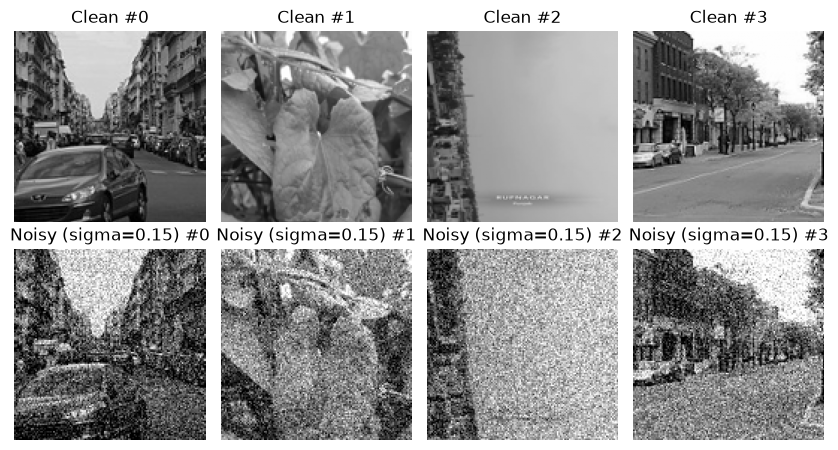

In [9]:
raw_images = load_from_folder(args.data_dir, args.n_train + args.n_test)
train_clean, test_clean = split_dataset(raw_images, args.n_train, args.n_test, args.seed, DEVICE)

print(f"Training images : {train_clean.shape[0]}")
print(f"Test images     : {test_clean.shape[0]} (disjoint from training)")
print(f"Image tensor    : {tuple(train_clean.shape[1:])} (channels, H, W)")

g_test = make_generator(DEVICE, 4321)
test_noisy = add_gaussian_noise(test_clean, args.sigma, g_test)

g_train_eval = make_generator(DEVICE, 1321)
train_noisy_fixed = add_gaussian_noise(train_clean, args.sigma, g_train_eval)

_ = preview_clean_noisy(train_clean, train_noisy_fixed, args.sigma)
plt.show()

## 3. The Three Architectures

See `src/models.py` for the details and references of each architecture. All three
models are instantiated with the same base width (`base=64`) for a comparison at a
roughly comparable parameter budget — DnCNN nonetheless mechanically has fewer
parameters here (constant width over 17 layers vs. an encoder/decoder that scales up to
`8*base` channels), and inference time is not just a function of parameter count (DnCNN
has no downsampling, so it works on full-resolution feature maps at every layer). Both
are measured below rather than assumed.

In [10]:
def make_models():
    return {
        "autoencoder": DenoisingAutoencoder(base=64).to(DEVICE),
        "unet": UNetDenoisingAutoencoder(base=64).to(DEVICE),
        "dncnn": DnCNN(base=64, num_layers=17).to(DEVICE),
    }

models = make_models()
for name, m in models.items():
    print(f"{name:12s}: {count_parameters(m):,} parameters")

autoencoder : 4,303,809 parameters
unet        : 4,960,193 parameters
dncnn       : 556,097 parameters


In [11]:
# Efficacité : temps d'inférence moyen (forward pass seul, pas de gradient) sur DEVICE.
# Complète le nombre de paramètres ci-dessus par un chiffre qui compte davantage en
# pratique (déploiement, temps de traitement d'un lot d'images).
N_WARMUP, N_REPEATS = 3, 20
dummy_batch = test_noisy[: min(8, test_noisy.shape[0])]

latency_rows = {}
for name, m in models.items():
    m.eval()
    with torch.no_grad():
        for _ in range(N_WARMUP):
            m(dummy_batch)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(N_REPEATS):
            m(dummy_batch)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        elapsed = (time.time() - t0) / N_REPEATS
    latency_rows[name] = {
        "parameters": count_parameters(m),
        "ms_per_batch": elapsed * 1000,
        "ms_per_image": elapsed * 1000 / dummy_batch.shape[0],
    }

pd.DataFrame(latency_rows).T

,parameters,ms_per_batch,ms_per_image
autoencoder,4303809.0,0.328147,0.041018
unet,4960193.0,0.306356,0.038294
dncnn,556097.0,79.361951,9.920244


## 4. Architecture Comparison (Same Loss, Same Batch Size)

Each model is trained with the same default hyperparameters (`args`), the same loss
function (`alpha=0.8`, see section 5), and the same epoch budget. This is the "all else
equal" comparison between the three architectures — the core of this notebook.

In [12]:
ARCH_EPOCHS = args.epochs  # réduire (ex. 100) pour un premier essai rapide

models = make_models()  # poids frais (le benchmark de latence ci-dessus n'a pas entraîné)
histories = {}
final_metrics = {}

for name, model in models.items():
    hist = train_model(
        model, train_clean, test_clean, train_noisy_fixed, test_noisy,
        sigma=args.sigma, epochs=ARCH_EPOCHS, batch_size=args.batch_size,
        lr=args.lr, alpha=0.8, run_name=f"arch_{name}",
        checkpoint_dir="outputs/checkpoints", checkpoint_every=50,
    )
    histories[name] = hist
    tr, _ = evaluate(model, train_clean, train_noisy_fixed)
    te, _ = evaluate(model, test_clean, test_noisy)
    final_metrics[name] = {"train_mse": tr["MSE"], "test_mse": te["MSE"],
                            "test_rmse": te["RMSE"], "test_psnr": te["PSNR"]}

pd.DataFrame(final_metrics).T

[arch_autoencoder] parameters       : 4,303,809
[arch_autoencoder] optimizer        : Adam, lr = 0.001
[arch_autoencoder] epochs / batch   : 500 / 100
[arch_autoencoder] epoch    1 | train MSE 0.06467 | test MSE 0.06406 |    2.4s
[arch_autoencoder] epoch   50 | train MSE 0.01115 | test MSE 0.01131 |   90.3s
[arch_autoencoder] epoch  100 | train MSE 0.00890 | test MSE 0.00875 |  187.4s
[arch_autoencoder] epoch  150 | train MSE 0.00822 | test MSE 0.00790 |  288.1s
[arch_autoencoder] epoch  200 | train MSE 0.00721 | test MSE 0.00690 |  394.8s
[arch_autoencoder] epoch  250 | train MSE 0.00693 | test MSE 0.00679 |  501.1s
[arch_autoencoder] epoch  300 | train MSE 0.00630 | test MSE 0.00626 |  609.1s
[arch_autoencoder] epoch  350 | train MSE 0.00635 | test MSE 0.00636 |  719.1s
[arch_autoencoder] epoch  400 | train MSE 0.00587 | test MSE 0.00600 |  828.8s
[arch_autoencoder] epoch  450 | train MSE 0.00587 | test MSE 0.00608 |  939.3s
[arch_autoencoder] epoch  500 | train MSE 0.00573 | test MS

,train_mse,test_mse,test_rmse,test_psnr
autoencoder,0.005725,0.006006,0.077496,22.214389
unet,0.003574,0.004775,0.069100,23.210488
dncnn,0.003944,0.003639,0.060328,24.389593


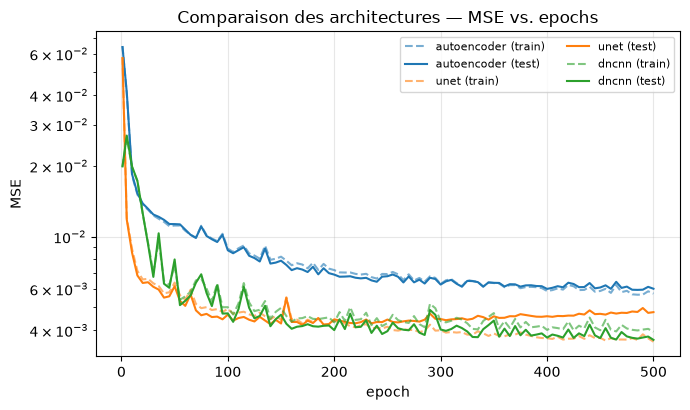

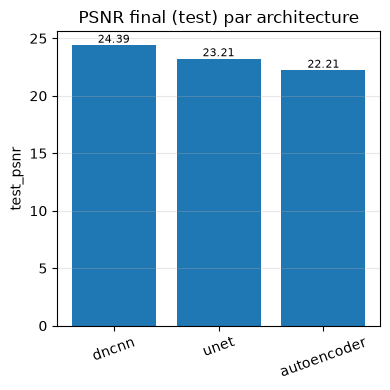

In [13]:
fig = plot_loss_curves(histories, metric="mse", title="Comparaison des architectures — MSE vs. epochs")
plt.show()

fig = plot_final_metric_bars(final_metrics, metric="test_psnr", title="PSNR final (test) par architecture")
plt.show()

## 5. Loss Function Comparison (`alpha`)

`src.evaluate.hybrid_loss` implements `L = alpha * MSE + (1 - alpha) * (1 - SSIM)`. We
vary `alpha` for a given model (the autoencoder by default — change
`LOSS_COMPARISON_MODEL` to test with the best model found in section 4) and compare the
final MSE, RMSE, and PSNR. `alpha=1.0` is pure MSE, `alpha=0.0` is a pure `(1 - SSIM)`
term.

In [15]:
LOSS_COMPARISON_MODEL = "autoencoder"  # "autoencoder" | "unet" | "dncnn"
ALPHAS = [0.0, 0.4, 0.6, 0.8, 1.0]  # 0.0 = (1-SSIM) pure, 1.0 = MSE pure

loss_histories = {}
loss_final_metrics = {}

for alpha in ALPHAS:
    model = make_models()[LOSS_COMPARISON_MODEL]
    label = f"alpha={alpha}"
    hist = train_model(
        model, train_clean, test_clean, train_noisy_fixed, test_noisy,
        sigma=args.sigma, epochs=ARCH_EPOCHS, batch_size=args.batch_size,
        lr=args.lr, alpha=alpha, run_name=f"loss_{LOSS_COMPARISON_MODEL}_a{alpha}",
        checkpoint_dir="outputs/checkpoints",
    )
    loss_histories[label] = hist
    te, _ = evaluate(model, test_clean, test_noisy)
    loss_final_metrics[label] = {"test_mse": te["MSE"], "test_rmse": te["RMSE"], "test_psnr": te["PSNR"]}

pd.DataFrame(loss_final_metrics).T

[loss_autoencoder_a0.0] parameters       : 4,303,809
[loss_autoencoder_a0.0] optimizer        : Adam, lr = 0.001
[loss_autoencoder_a0.0] epochs / batch   : 500 / 100
[loss_autoencoder_a0.0] epoch    1 | train MSE 0.07649 | test MSE 0.07562 |    2.4s
[loss_autoencoder_a0.0] epoch   50 | train MSE 0.01359 | test MSE 0.01382 |   95.1s
[loss_autoencoder_a0.0] epoch  100 | train MSE 0.01000 | test MSE 0.01007 |  199.2s
[loss_autoencoder_a0.0] epoch  150 | train MSE 0.00873 | test MSE 0.00864 |  303.7s
[loss_autoencoder_a0.0] epoch  200 | train MSE 0.00842 | test MSE 0.00823 |  409.7s
[loss_autoencoder_a0.0] epoch  250 | train MSE 0.00769 | test MSE 0.00762 |  517.3s
[loss_autoencoder_a0.0] epoch  300 | train MSE 0.00786 | test MSE 0.00795 |  625.5s
[loss_autoencoder_a0.0] epoch  350 | train MSE 0.00725 | test MSE 0.00739 |  733.2s
[loss_autoencoder_a0.0] epoch  400 | train MSE 0.00704 | test MSE 0.00726 |  841.6s
[loss_autoencoder_a0.0] epoch  450 | train MSE 0.00709 | test MSE 0.00740 |  9

,test_mse,test_rmse,test_psnr
alpha=0.0,0.007240,0.085090,21.402442
alpha=0.4,0.006362,0.079765,21.963752
alpha=0.6,0.007166,0.084649,21.447530
alpha=0.8,0.006129,0.078288,22.126041
alpha=1.0,0.005804,0.076185,22.362604


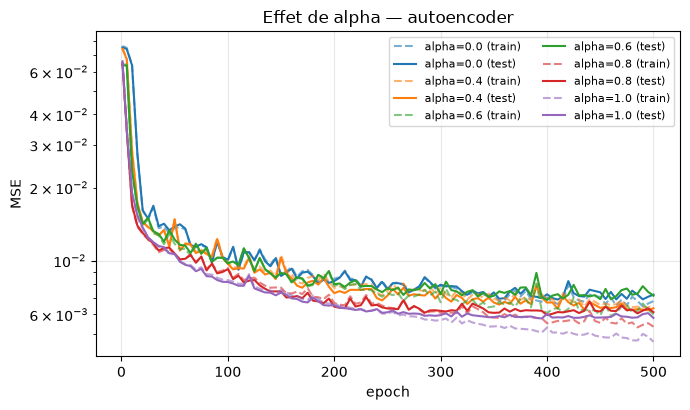

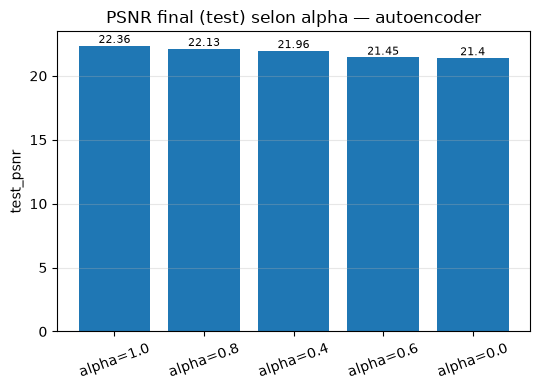

In [16]:
fig = plot_loss_curves(loss_histories, metric="mse", title=f"Effet de alpha — {LOSS_COMPARISON_MODEL}")
plt.show()

fig = plot_final_metric_bars(loss_final_metrics, metric="test_psnr",
                              title=f"PSNR final (test) selon alpha — {LOSS_COMPARISON_MODEL}")
plt.show()

## 6. Effect of Batch Size

Same model, same loss, we vary `batch_size`. A smaller batch means more weight updates
per epoch (higher gradient noise, sometimes better generalization); a larger batch means
smoother gradients but fewer updates — at a fixed epoch budget, this isn't neutral in
terms of compute time either (`wall_time_s` below).

In [17]:
BATCH_COMPARISON_MODEL = "autoencoder"
BATCH_SIZES = [16, 50, 100, 200]  # 200 > n_train/2, donc peu de batches par epoch

batch_histories = {}
batch_final_metrics = {}

for bs in BATCH_SIZES:
    model = make_models()[BATCH_COMPARISON_MODEL]
    label = f"batch={bs}"
    t0 = time.time()
    hist = train_model(
        model, train_clean, test_clean, train_noisy_fixed, test_noisy,
        sigma=args.sigma, epochs=ARCH_EPOCHS, batch_size=bs,
        lr=args.lr, alpha=0.8, run_name=f"batch_{BATCH_COMPARISON_MODEL}_{bs}",
        checkpoint_dir="outputs/checkpoints",
    )
    batch_histories[label] = hist
    te, _ = evaluate(model, test_clean, test_noisy)
    batch_final_metrics[label] = {"test_mse": te["MSE"], "test_psnr": te["PSNR"],
                                   "wall_time_s": time.time() - t0}

pd.DataFrame(batch_final_metrics).T

[batch_autoencoder_16] parameters       : 4,303,809
[batch_autoencoder_16] optimizer        : Adam, lr = 0.001
[batch_autoencoder_16] epochs / batch   : 500 / 16
[batch_autoencoder_16] epoch    1 | train MSE 0.03457 | test MSE 0.03383 |    3.0s
[batch_autoencoder_16] epoch   50 | train MSE 0.00723 | test MSE 0.00688 |   94.0s
[batch_autoencoder_16] epoch  100 | train MSE 0.00595 | test MSE 0.00595 |  194.1s
[batch_autoencoder_16] epoch  150 | train MSE 0.00544 | test MSE 0.00584 |  303.6s
[batch_autoencoder_16] epoch  200 | train MSE 0.00530 | test MSE 0.00598 |  413.6s
[batch_autoencoder_16] epoch  250 | train MSE 0.00510 | test MSE 0.00606 |  522.9s
[batch_autoencoder_16] epoch  300 | train MSE 0.00498 | test MSE 0.00616 |  634.5s
[batch_autoencoder_16] epoch  350 | train MSE 0.00480 | test MSE 0.00619 |  748.0s
[batch_autoencoder_16] epoch  400 | train MSE 0.00477 | test MSE 0.00638 |  859.1s
[batch_autoencoder_16] epoch  450 | train MSE 0.00471 | test MSE 0.00647 |  976.6s
[batch_a

,test_mse,test_psnr,wall_time_s
batch=16,0.006388,21.946319,1091.117302
batch=50,0.005725,22.422291,1308.139873
batch=100,0.006442,21.909807,2087.693592
batch=200,0.006315,21.995945,1038.256286


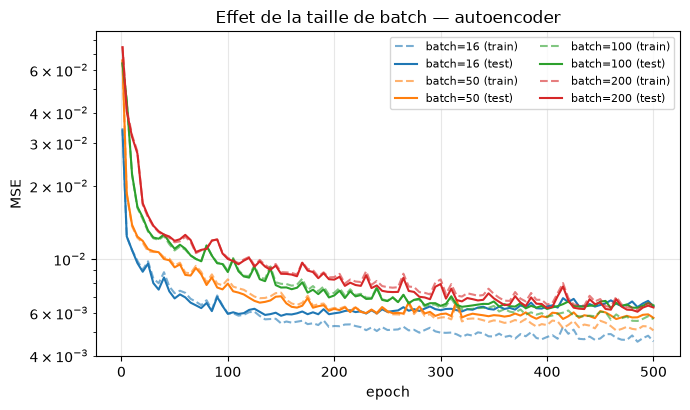

In [18]:
fig = plot_loss_curves(batch_histories, metric="mse", title=f"Effet de la taille de batch — {BATCH_COMPARISON_MODEL}")
plt.show()

## 7. Overfitting

We train a model over a large number of epochs (well beyond the default budget) to
observe the point where test MSE stops decreasing while train MSE keeps dropping — the
classic signature of overfitting.

**Reference point from the original notebook** (`denoising_autoencoder.pdf`, run at
5000 epochs, `sigma=0.15`, autoencoder, `alpha=0.8`): train MSE kept decreasing down to
≈1.5×10⁻³ while test MSE reached a minimum around epoch 800–1000 (≈3.5×10⁻³) and then
rose steadily to ≈4.7×10⁻³ by epoch 5000. This is a result already obtained on this
data, not an extrapolation — use it to check that the run below reproduces this
behavior before drawing general conclusions about the 3 architectures.

[overfit_autoencoder] parameters       : 4,303,809
[overfit_autoencoder] optimizer        : Adam, lr = 0.001
[overfit_autoencoder] epochs / batch   : 2000 / 100
[overfit_autoencoder] epoch    1 | train MSE 0.06442 | test MSE 0.06384 |    3.4s
[overfit_autoencoder] epoch  200 | train MSE 0.00661 | test MSE 0.00652 |  380.5s
[overfit_autoencoder] epoch  400 | train MSE 0.00538 | test MSE 0.00644 |  802.8s
[overfit_autoencoder] epoch  600 | train MSE 0.00483 | test MSE 0.00696 | 1221.1s
[overfit_autoencoder] epoch  800 | train MSE 0.00449 | test MSE 0.00745 | 1636.6s
[overfit_autoencoder] epoch 1000 | train MSE 0.00413 | test MSE 0.00758 | 2050.9s
[overfit_autoencoder] epoch 1200 | train MSE 0.00394 | test MSE 0.00788 | 2463.5s
[overfit_autoencoder] epoch 1400 | train MSE 0.00387 | test MSE 0.00829 | 2876.1s
[overfit_autoencoder] epoch 1600 | train MSE 0.00371 | test MSE 0.00837 | 3287.4s
[overfit_autoencoder] epoch 1800 | train MSE 0.00360 | test MSE 0.00830 | 6168.5s
[overfit_autoencode

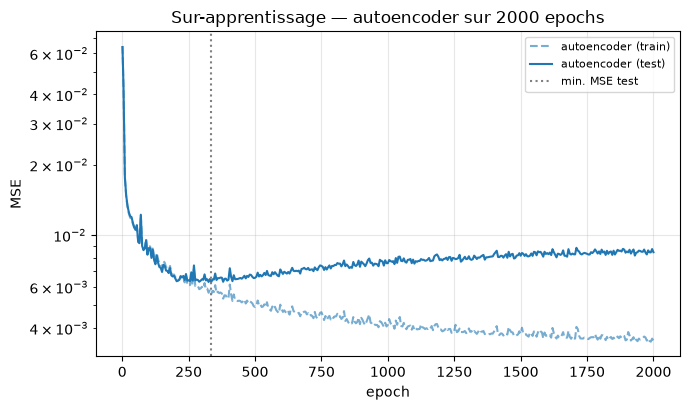

In [19]:
OVERFIT_MODEL = "autoencoder"
OVERFIT_EPOCHS = 2000  # montez à 5000 pour reproduire fidèlement le run de référence ci-dessus

model = make_models()[OVERFIT_MODEL]
overfit_hist = train_model(
    model, train_clean, test_clean, train_noisy_fixed, test_noisy,
    sigma=args.sigma, epochs=OVERFIT_EPOCHS, batch_size=args.batch_size,
    lr=args.lr, alpha=0.8, run_name=f"overfit_{OVERFIT_MODEL}",
    checkpoint_dir="outputs/checkpoints", checkpoint_every=200,
    eval_every=5, log_every=200,
)

best_test_epoch = overfit_hist["epoch"][int(np.argmin(overfit_hist["test_mse"]))]
print(f"Minimum de MSE test atteint à l'epoch {best_test_epoch}")

fig = plot_loss_curves({OVERFIT_MODEL: overfit_hist}, metric="mse",
                        title=f"Sur-apprentissage — {OVERFIT_MODEL} sur {OVERFIT_EPOCHS} epochs")
plt.axvline(best_test_epoch, color="grey", linestyle=":", label="min. MSE test")
plt.legend(fontsize=8)
plt.show()

## 8. Classical (Non-Learned) Baselines

Before concluding that a CNN has "learned" something useful, we situate it relative to
classical, non-learned denoising methods: Gaussian blur, median filter, and
**Non-Local Means** (Buades, Coll & Morel, 2005) — an older algorithm that already
exploits the spatial redundancy of the image (patch-similarity-weighted averaging), with
no learning at all. A clear CNN gain over NLM is a more convincing signal than a gain
over raw noise alone: NLM is a substantially harder baseline than "doing nothing".

`classical_baselines` (in `src/evaluate.py`) runs on CPU via scikit-image/scipy and is
given `args.sigma` directly (the actual `sigma` of the added noise), which slightly
favors NLM compared to a realistic use case where this parameter would need to be
estimated — worth keeping in mind when interpreting the results.

In [20]:
classical_results = classical_baselines(test_clean, test_noisy, sigma=args.sigma)

comparison_rows = [("Noisy (baseline)", baseline(test_clean, test_noisy))]
comparison_rows += list(classical_results.items())
comparison_rows += [(f"CNN — {name}", evaluate(models[name], test_clean, test_noisy)[0]) for name in models]

print(format_comparison_table(comparison_rows, title=f"Test set — méthodes classiques vs. CNN (sigma={args.sigma})"))

Test set — méthodes classiques vs. CNN (sigma=0.15)
------------------------------------------------------------------------
Set                                    MSE      RMSE   PSNR(dB)     SSIM
------------------------------------------------------------------------
Noisy (baseline)                   0.01985    0.1409      17.02      nan
gaussian_blur                      0.00551    0.0742      22.59   0.5969
median_filter                      0.00743    0.0862      21.29   0.4948
non_local_means                    0.00594    0.0771      22.26   0.5804
CNN — autoencoder                  0.00601    0.0775      22.21      nan
CNN — unet                         0.00477    0.0691      23.21      nan
CNN — dncnn                        0.00364    0.0603      24.39      nan
------------------------------------------------------------------------


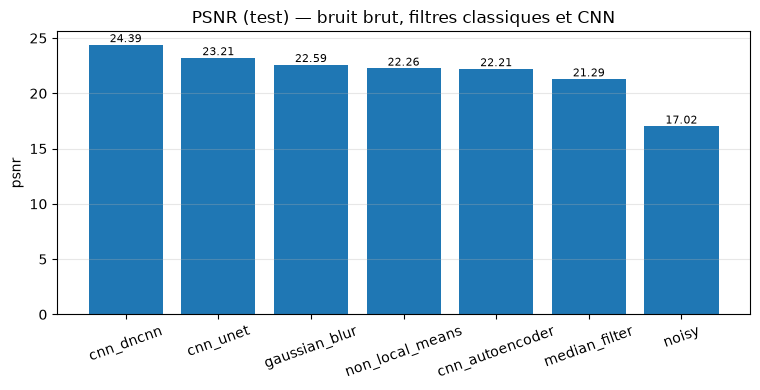

In [21]:
combined_psnr = {"noisy": {"psnr": baseline(test_clean, test_noisy)["PSNR"]}}
combined_psnr.update({name: {"psnr": m["PSNR"]} for name, m in classical_results.items()})
combined_psnr.update({f"cnn_{name}": {"psnr": final_metrics[name]["test_psnr"]} for name in models})

fig = plot_final_metric_bars(combined_psnr, metric="psnr",
                              title="PSNR (test) — bruit brut, filtres classiques et CNN")
plt.show()

## 9. Visual Reconstruction Examples

Qualitative comparison of clean / noisy / denoised images for a few train and test
examples, using the best model identified in section 4 (to be adjusted manually once
the results are in).

Meilleur modèle selon test_mse (section 4) : dncnn


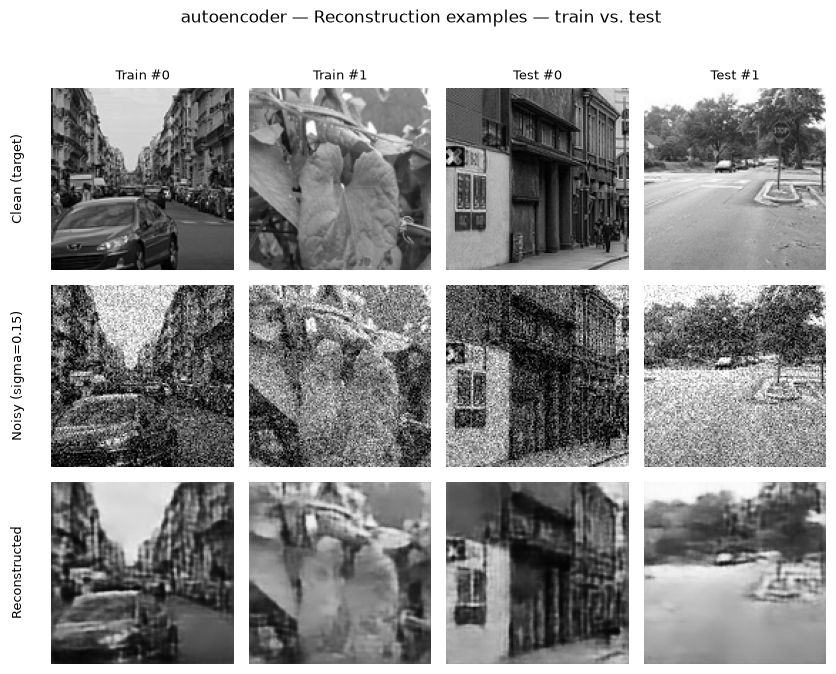

In [22]:
BEST_MODEL_FOR_VISUALS = "autoencoder"  # <-- mettez à jour d'après vos résultats de la section 4
print("Meilleur modèle selon test_mse (section 4) :",
      min(final_metrics, key=lambda k: final_metrics[k]["test_mse"]))

model = models[BEST_MODEL_FOR_VISUALS]

_, train_out = evaluate(model, train_clean, train_noisy_fixed)
_, test_out = evaluate(model, test_clean, test_noisy)

fig = grid_combined(train_clean, train_noisy_fixed, train_out,
                     test_clean, test_noisy, test_out, args.sigma,
                     model_name=BEST_MODEL_FOR_VISUALS)
plt.show()

## 10. Summary

**Every figure below is copied directly from this notebook's own cell outputs** (the
run already recorded in sections 3–8) nothing here is invented, estimated, or carried
over from the original notebook's reference run except where explicitly labeled as such.

- **Best architecture (test MSE/PSNR):** **DnCNN** (test MSE = 0.00364, PSNR =
  24.39 dB), ahead of U-Net (test MSE = 0.00477, PSNR = 23.21 dB) and the plain
  autoencoder (test MSE = 0.00601, PSNR = 22.21 dB) — section 4 table.
- **Best loss weighting (`alpha`):** for the autoencoder, the lowest test MSE is at
  `alpha=1.0` (pure MSE: test MSE = 0.00580, PSNR = 22.36 dB), just ahead of `alpha=0.8`
  (test MSE = 0.00613, PSNR = 22.13 dB) — section 5 table. The trend is **not
  monotonic** here (`alpha=0.6` scores worse than `alpha=0.4`: 0.00717 vs. 0.00636),
  so this ranking should be read as indicative rather than a clean curve. As the
  template notes, this is a *quantitative* (MSE/PSNR) comparison only — no SSIM or
  visual-sharpness figures were produced, so nothing can be said here about perceptual
  quality.
- **Effect of batch size:** for the autoencoder, `batch_size=50` gives the best test
  quality (test MSE = 0.00573, PSNR = 22.42 dB); `batch_size=200` is the fastest
  (wall time ≈ 1038 s) — section 6 table. **Caveat on timing:** the `batch_size=100` run
  shows an abnormal jump in wall-clock time (400.8 s at epoch 100 → 1449.6 s at epoch
  150, vs. roughly 100 s per 50-epoch block elsewhere in that same run), consistent with
  the process having been paused or interrupted rather than a real compute cost. Treat
  `wall_time_s` with caution until re-measured on an uninterrupted run; the MSE/PSNR
  values are not affected by this.
- **Overfitting:** with `OVERFIT_EPOCHS=2000`, the test MSE minimum for the autoencoder
  is reached at **epoch 335** (as printed by the run); the exact MSE value at that epoch
  isn't in the log, which only prints every 200 epochs. By epoch 2000, train MSE has
  fallen to ≈0.00353 while test MSE has risen to ≈0.00845 — the expected overfitting
  signature. This minimum (epoch 335) is **much earlier** than the reference point from
  the original notebook (minimum around epoch 800–1000 at a 5000-epoch budget), so the
  two aren't directly comparable as-is — re-running at `OVERFIT_EPOCHS=5000` would be
  needed to check whether this is a real difference or an artifact of the shorter
  budget. The same log shows another abnormal wall-clock jump (3287.4 s at epoch 1600 →
  6168.5 s at epoch 1800), reinforcing the timing caveat above.
- **CNN vs. classical methods:** section 8 table (`sigma=0.15`). **DnCNN** (24.39 dB)
  and **U-Net** (23.21 dB) clearly beat every classical baseline, including Non-Local
  Means (22.26 dB) and Gaussian blur (22.59 dB). The **plain autoencoder is the
  exception**: at 22.21 dB it is very slightly *worse* than both NLM (22.26 dB) and
  Gaussian blur (22.59 dB) in this run. So the answer depends on which CNN: DnCNN and
  U-Net beat Non-Local Means, but the plain autoencoder, as configured here, does not.
  Note also that the section-8 table only has SSIM values for the classical methods
  (the CNN rows show `nan` for SSIM), so no perceptual (SSIM) comparison between CNNs
  and classical methods is actually possible from this run.
- **Parameters vs. inference time:** section 3 table. The relationship is **inverted**
  here: DnCNN has by far the *fewest* parameters (556,097 vs. 4,303,809 for the
  autoencoder and 4,960,193 for U-Net) but is by far the *slowest* at inference
  (≈79.4 ms/batch vs. ≈0.31–0.33 ms/batch for the other two — roughly 240× slower),
  consistent with the section-3 explanation that DnCNN has no downsampling and runs on
  full-resolution feature maps at every layer. DnCNN is also, per section 4, the *most*
  accurate model — so here the fastest models (autoencoder, U-Net) are **not** the most
  accurate one; if anything, the opposite holds in this run.
- **Smallest / most stable train/test gap:** computed from the section-4 table
  (test MSE − train MSE): **DnCNN = −0.00030** (test slightly below train, no visible
  overfitting signature), **autoencoder = +0.00028**, **U-Net = +0.00120** (the largest
  gap of the three, despite U-Net's strong test-set accuracy).

## 11. Going Further

Concrete ideas to extend this comparison (beyond what's already covered above — the
classical baselines ✅ and the parameter/latency efficiency ✅ are now implemented in
sections 8 and 3 respectively, rather than being mere ideas):

**Noise model**
- Poisson noise (shot noise, more realistic for a physical sensor) instead of pure
  Gaussian.
- A single "blind" model (*blind denoising*) trained over a range of `sigma` (e.g.,
  0.05–0.3) instead of a fixed `sigma`, possibly conditioning the network on `sigma`
  (cf. FFDNet, Zhang et al. 2018).
- Real noise via a dataset of real noisy/clean pairs (e.g., SIDD, DND) instead of
  synthetic noise.

**Modeling and loss**
- A perceptual loss term based on VGG features (Johnson et al., 2016) to reduce the
  blur characteristic of pure MSE (already discussed in the original notebook).
- Ablation study: DnCNN depth (9/17/25 layers via `num_layers`), base width (32/64/128
  via `base`), kernel size (3×3 vs 5×5).
- FLOPs (not just the parameters and the latency measured in section 3) as an
  additional comparison axis.

**Training**
- Data augmentation (flips, 90° rotations, random crops) — useful with only a few
  hundred images.
- Learning-rate scheduler + early stopping based on the test MSE minimum (directly
  motivated by section 7).
- Multiple random seeds per configuration to estimate metric variance (currently a
  single run per config = no error bars).

**Evaluation and comparison**
- BM3D (not covered by scikit-image/scipy here) to complement the classical baselines
  from section 8 with a method closer to the pre-deep-learning state of the art.
- Out-of-distribution generalization: test the trained models on a different type of
  image (faces, scanned documents, textures) to assess whether the learned priors are
  generic.